In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data=pd.read_csv('delivery_performance_dataset.csv',encoding='latin-1')
delivery_df=pd.DataFrame(data)

Delivary Performance

In [3]:
delivery_df['Delay_Days']=delivery_df['Days for shipping (real)']-delivery_df['Days for shipment (scheduled)']
total_orders = len(delivery_df)
on_time_rate = ((delivery_df['Delay_Days'] <= 0).mean()* 100)
late_rate = ((delivery_df['Delay_Days'] > 0).mean()* 100)
avg_shipping_days = (delivery_df['Days for shipping (real)'].mean())

print(f"Total Orders          : {total_orders:,}")
print(f"On-Time Delivery Rate : {on_time_rate:.2f}%")
print(f"Late Delivery Rate    : {late_rate:.2f}%")
print(f"Average Shipping Days : {avg_shipping_days:.2f}")

Total Orders          : 180,519
On-Time Delivery Rate : 42.72%
Late Delivery Rate    : 57.28%
Average Shipping Days : 3.50


1. Delivery Status Distribution

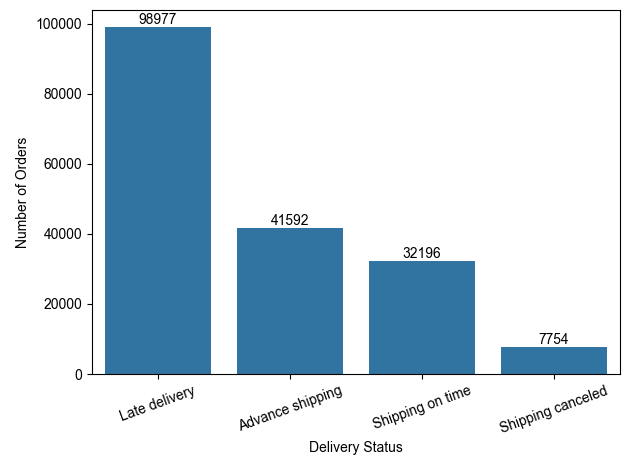

In [4]:

# 1.Count delivery status
ax=sns.barplot(delivery_df['Delivery Status'].value_counts())
ax.bar_label(ax.containers[0], fontsize=10)
sns.color_palette('dark')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=20)
plt.tight_layout()
sns.set_style('darkgrid')
plt.show()

2. Late Delivery Risk Distribution

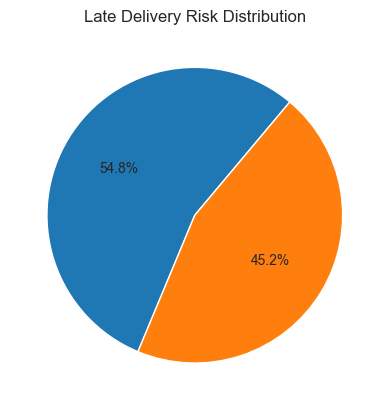

In [5]:
plt.pie(delivery_df['Late_delivery_risk'].value_counts(),autopct='%1.1f%%',startangle=50)
sns.color_palette('dark')
plt.title('Late Delivery Risk Distribution')
plt.ylabel('')
plt.show()

3. Actual vs Scheduled Shipping Days

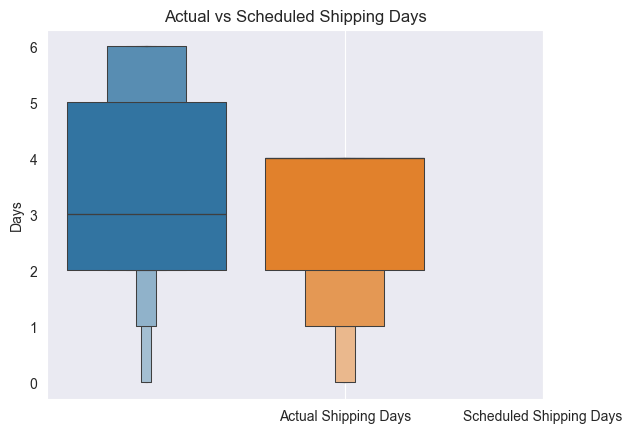

In [6]:
sns.boxenplot([delivery_df['Days for shipping (real)'],delivery_df['Days for shipment (scheduled)']])
plt.xticks([1, 2], ['Actual Shipping Days', 'Scheduled Shipping Days'])
plt.title('Actual vs Scheduled Shipping Days')
plt.ylabel('Days')
sns.set_style('darkgrid')
plt.grid()
plt.show()

4. Average Delay by Shipping Mode

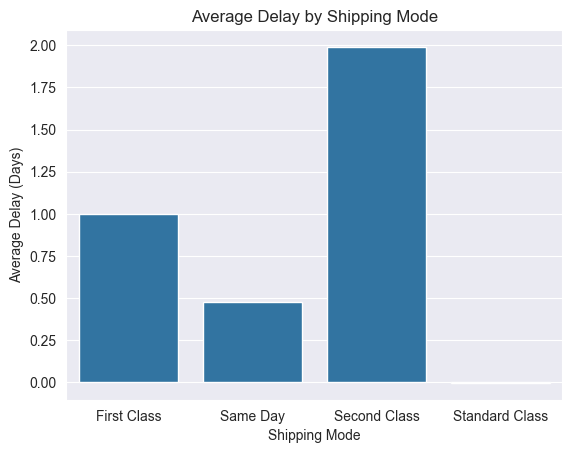

In [15]:
avg_delay = delivery_df.groupby('Shipping Mode')['Delay_Days'].mean()
sns.barplot(avg_delay)
plt.title('Average Delay by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Average Delay (Days)')
plt.show()

5. Late Delivery Rate by Shipping Mode

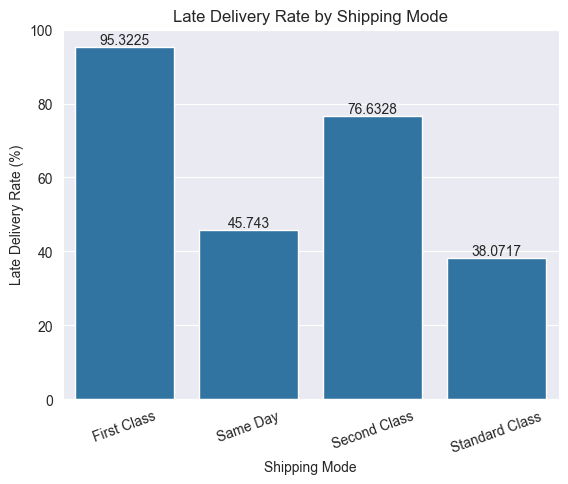

In [8]:
late_rate = delivery_df.groupby('Shipping Mode')['Late_delivery_risk'].mean()* 100
ax=sns.barplot(late_rate)
ax.bar_label(ax.containers[0], fontsize=10)
plt.title('Late Delivery Rate by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=20)
plt.show()

6. Delivery Performance by Region

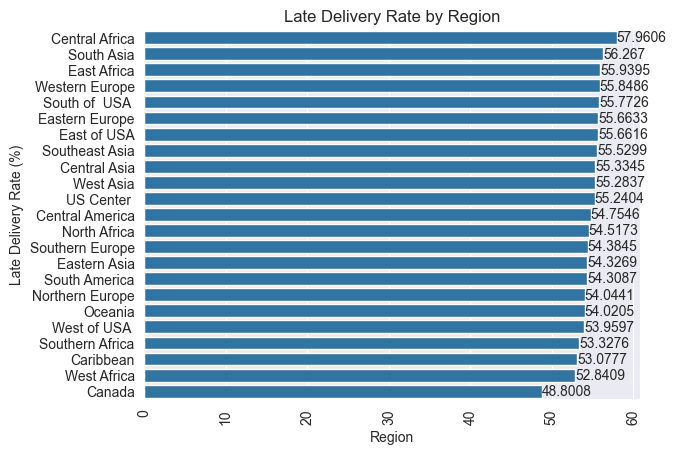

In [9]:
region_performance = (delivery_df.groupby('Order Region')['Late_delivery_risk'].mean()* 100).sort_values(ascending=False)
ax=sns.barplot(region_performance,orient='h')
ax.bar_label(ax.containers[0], fontsize=10)
plt.title('Late Delivery Rate by Region')
plt.xlabel('Region')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=90)
plt.show()

7. Delivery Performance by Country

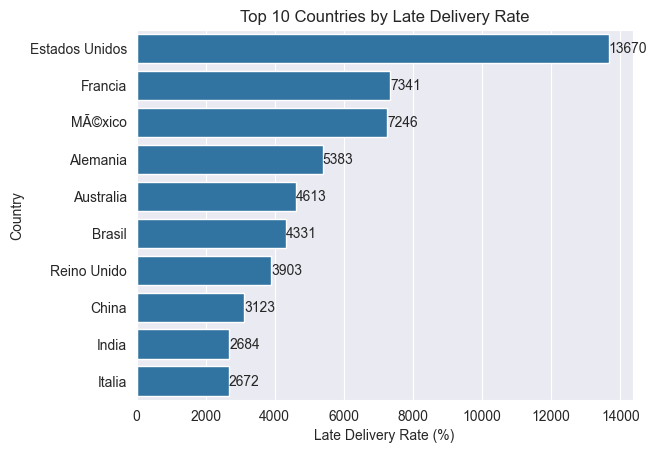

In [10]:
top_countries = (delivery_df.groupby('Order Country')['Late_delivery_risk'].sum().sort_values(ascending=False).head(10))
ax=sns.barplot(top_countries,orient='h')
ax.bar_label(ax.containers[0], fontsize=10)
plt.title('Top 10 Countries by Late Delivery Rate')
plt.xlabel('Late Delivery Rate (%)')
plt.ylabel('Country')
plt.show()

8. Monthly Delivery Trend

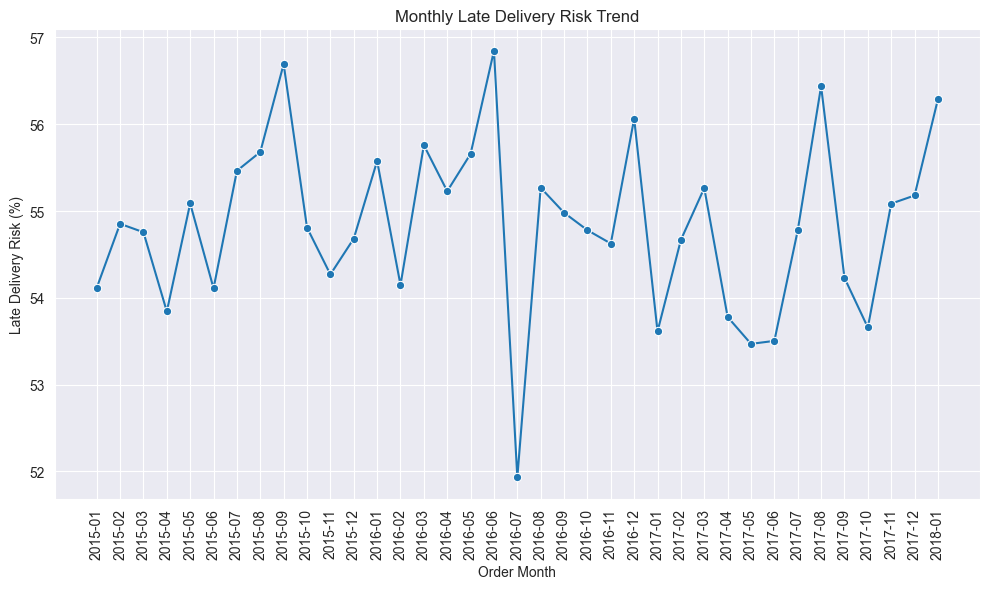

In [11]:
delivery_df['order date (DateOrders)'] = pd.to_datetime(delivery_df['order date (DateOrders)'])
delivery_df['Order Month'] = delivery_df['order date (DateOrders)'].dt.strftime('%Y-%m')
monthly_trend = (delivery_df.groupby('Order Month')['Late_delivery_risk'].mean() * 100).sort_index()
monthly_trend_df = monthly_trend.reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_trend_df, x='Order Month', y='Late_delivery_risk', marker='o',)
plt.title('Monthly Late Delivery Risk Trend')
plt.xlabel('Order Month')
plt.ylabel('Late Delivery Risk (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


9. Delivery Delay Distribution

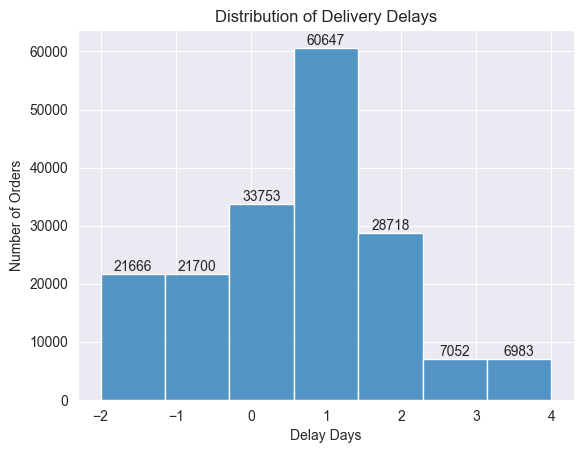

In [16]:
ax=sns.histplot(delivery_df['Delay_Days'],bins=7)
ax.bar_label(ax.containers[0], fontsize=10)
plt.title('Distribution of Delivery Delays')
plt.xlabel('Delay Days')
plt.ylabel('Number of Orders')
plt.show()

10. Heatmap: Region × Shipping Mode

In [13]:
pivot_table = pd.pivot_table(delivery_df,values='Late_delivery_risk',index='Order Region',columns='Shipping Mode',aggfunc='mean') * 100
pivot_table

Shipping Mode,First Class,Same Day,Second Class,Standard Class
Order Region,,,,
Canada,92.391304,21.212121,75.301205,28.819444
Caribbean,94.886840,49.667406,78.295524,35.336109
Central Africa,92.666667,30.379747,81.144781,42.857143
Central America,95.504336,45.748419,75.004561,38.528291
Central Asia,100.000000,20.312500,86.324786,41.747573
East Africa,98.928571,41.836735,77.071823,39.478417
East of USA,96.418733,47.846890,74.804382,39.782082
Eastern Asia,94.822627,47.536946,79.374111,37.446328
Eastern Europe,96.048632,35.955056,74.870466,39.273356


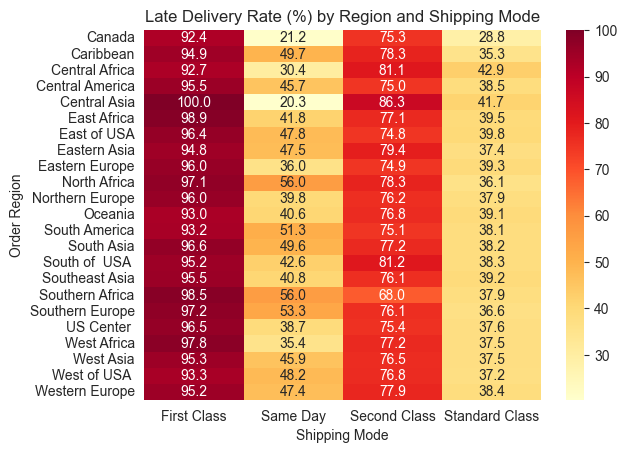

In [14]:
sns.heatmap(pivot_table,annot=True,fmt='.1f',cmap='YlOrRd')
plt.title('Late Delivery Rate (%) by Region and Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Order Region')
plt.show()